# ARMA Original Settings Reproduction — FIXED v2

# Synthetic ARMA Conditional Diffusion Experiment — Original Settings

This notebook is the GitHub/module version of the ARMA experiment from your original notebook.

The important point is that this notebook intentionally keeps the same ARMA data-generating process and training budget as the original:

- `T=8000`, `num_assets=5`, `sigma=0.01`, `corr=0.30`
- `context_length=24`
- LSTM hidden size `32`, `2` layers, dropout `0.1`
- U-Net base channels `32`, depth `1`
- `diffusion_steps=1000`
- `batch_size=256`, `epochs=300`
- generate `horizon=100`, `num_samples=2000`

The previous GitHub notebook used a smaller/faster configuration. That was useful for a quick demo, but it was **not** a faithful reproduction and can give much worse ARMA diagnostics.

In [2]:
cd /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model

/content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from portfolio_diffusion import (
    DDPMConfig,
    TrainCfg,
    ConditionalRecurrentDDPM,
    build_dataloader,
    fit,
    seed_everything,
    simulate_arma_returns,
    generate_scenarios,
    arma_distribution_diagnostics,
    acf1_numpy_centered,
    acf1_torch_scenarios_centered,
)

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "arma_original_settings"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

seed_everything(42)
print("Project root:", PROJECT_ROOT)
print("Output dir:", OUTPUT_DIR)
print("CUDA available:", torch.cuda.is_available())

Project root: /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model
Output dir: /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/outputs/arma_original_settings
CUDA available: True


## 1. Simulate ARMA returns

This is copied from the original experiment settings. No drift is added here, because the original ARMA diagnostic experiment focused on matching distributional moments and autocorrelation, not portfolio performance.

In [5]:
returns_raw = simulate_arma_returns(
    T=8000,
    num_assets=5,
    ar=(0.10, 0.04, 0.02, 0.01, 0.00),
    ma=(0.06, 0.03, 0.01, 0.00, 0.00),
    sigma=0.01,
    corr=0.30,
    seed=123,
)
asset_names = [f"Asset_{i+1}" for i in range(returns_raw.shape[1])]
dates = pd.period_range("1900-01", periods=len(returns_raw), freq="M")
returns_df = pd.DataFrame(returns_raw, index=dates, columns=asset_names)

print("Raw returns shape:", returns_raw.shape)
returns_df.head()

Raw returns shape: (8000, 5)


,Asset_1,Asset_2,Asset_3,Asset_4,Asset_5
1900-01,0.010934,0.007370,0.011726,0.010357,0.002787
1900-02,0.000559,-0.004683,0.013553,0.014500,0.002514
1900-03,0.002980,0.001879,-0.003001,0.010180,0.006684
1900-04,0.010232,-0.004166,-0.016639,0.005791,-0.014027
1900-05,0.006085,-0.000449,-0.005399,-0.017032,-0.006942


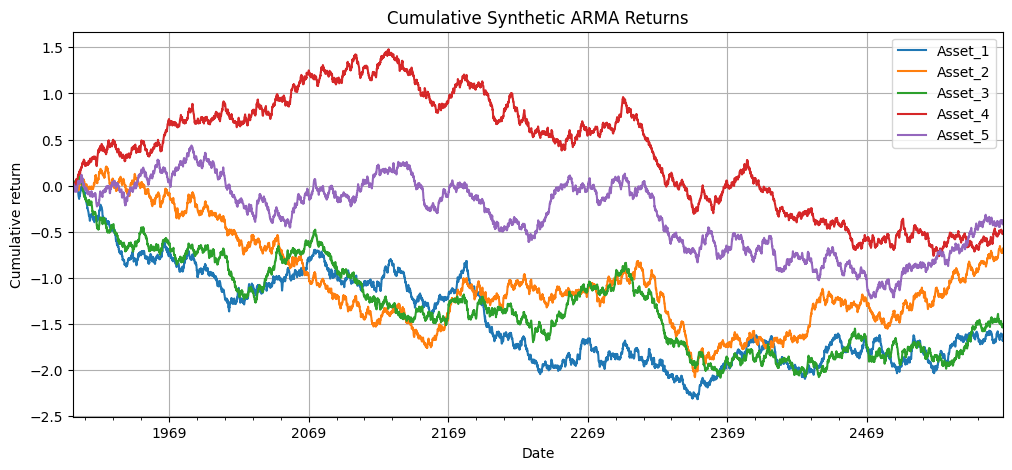

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
returns_df.cumsum().plot(ax=ax)
ax.set_title("Cumulative Synthetic ARMA Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.grid(True)
plt.show()

## 2. Configure DDPM model

These hyperparameters match the original notebook. The larger diffusion step count and longer training budget are important for reproducing the good ARMA result.

In [7]:
cfg = DDPMConfig(
    input_dim=returns_raw.shape[1],
    context_length=36,
    prediction_length=1,

    rnn_type="LSTM",
    rnn_hidden_dim=64,
    rnn_layers=2,
    rnn_dropout=0.1,

    unet_base_channels=32,
    unet_depth=1,
    time_embed_dim=128,

    diffusion_steps=1000,
    beta_start=1e-4,
    beta_end=2e-2,

    lr=2e-4,
    batch_size=256,
    epochs=300,
    grad_clip=1.0,
    weight_decay=1e-4,

    device="cuda" if torch.cuda.is_available() else "cpu",
)

device = torch.device(cfg.device)
print("Device:", device)
print(cfg)

Device: cuda
DDPMConfig(input_dim=5, context_length=36, prediction_length=1, rnn_type='LSTM', rnn_hidden_dim=64, rnn_layers=2, rnn_dropout=0.1, unet_base_channels=32, unet_depth=1, time_embed_dim=128, diffusion_steps=1000, beta_start=0.0001, beta_end=0.02, lr=0.0002, batch_size=256, epochs=300, grad_clip=1.0, weight_decay=0.0001, device='cuda', scale_condition=1.0)


In [8]:
# Sanity check: fail immediately if this notebook is not using the original ARMA settings.
assert returns_raw.shape == (8000, 5), returns_raw.shape
assert cfg.context_length == 36
assert cfg.prediction_length == 1
assert cfg.rnn_hidden_dim == 64
assert cfg.rnn_layers == 2
assert abs(cfg.rnn_dropout - 0.1) < 1e-12
assert cfg.unet_base_channels == 32
assert cfg.unet_depth == 1
assert cfg.diffusion_steps == 1000
assert cfg.batch_size == 256
assert cfg.epochs == 300
print("ARMA original settings sanity check passed.")

ARMA original settings sanity check passed.


## 3. Train/validation split and standardization

This follows the original split exactly: first 80% for training; validation includes a context overlap.

In [9]:
split_idx = int(0.80 * len(returns_raw))

train_raw = returns_raw[:split_idx]

# Validation needs context overlap, same as the original notebook.
valid_raw = returns_raw[split_idx - cfg.context_length:]
valid_dates = dates[split_idx - cfg.context_length:]

mean = train_raw.mean(axis=0, keepdims=True)
std = train_raw.std(axis=0, keepdims=True) + 1e-8

train_returns = (train_raw - mean) / std
valid_returns = (valid_raw - mean) / std

print("Train returns mean:", train_returns.mean(axis=0))
print("Train returns std:", train_returns.std(axis=0))
print("Train raw shape:", train_raw.shape)
print("Valid raw with context shape:", valid_raw.shape)

Train returns mean: [6.4438211e-08 1.9083963e-08 3.4384428e-08 5.3634867e-08 1.9557774e-08]
Train returns std: [0.99999696 0.99999976 0.9999985  0.999999   1.0000004 ]
Train raw shape: (6400, 5)
Valid raw with context shape: (1636, 5)


## 4. Dataloaders

The package uses the repo-style sequence-to-sequence target shape:

```text
context: [B, 24, 5]
target:  [B, 24, 1, 5]
```

So each RNN hidden state gets its own diffusion loss.

In [10]:
train_dataset, train_loader = build_dataloader(
    series=train_returns,
    cfg=cfg,
    shuffle=True,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=True,
)

valid_dataset, valid_loader = build_dataloader(
    series=valid_returns,
    cfg=cfg,
    shuffle=False,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=False,
)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))

batch = next(iter(train_loader))
print("context shape:", batch["context"].shape)
print("target shape:", batch["target"].shape)

Train samples: 6364
Valid samples: 1600
context shape: torch.Size([256, 36, 5])
target shape: torch.Size([256, 36, 1, 5])


## 5. Train

This uses the same training budget as your original successful ARMA notebook. On CPU this can be slow; on Colab GPU it is the setting that produced the good ACF/std matching.

In [11]:
model = ConditionalRecurrentDDPM(cfg).to(device)

train_cfg = TrainCfg(
    optim_name="AdamW",
    lr=2e-4,
    weight_decay=1e-4,
    scheduler="cosine",
    num_epochs=300,

    use_ema=True,
    ema_decay=0.999,

    max_grad_norm=1.0,
    amp=torch.cuda.is_available(),
    patience=20,

    seed=42,
    save_path=str(OUTPUT_DIR / "best_arma_return_ddpm.pt"),
    force_lazy_modules=True,
)

best_model, history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=valid_loader,
    device=device,
    cfg=train_cfg,
)

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
history_df.tail()

/content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/portfolio_diffusion/training.py:279: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
Epoch 1/300:   0%|          | 0/24 [00:00<?, ?it/s]/content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/portfolio_diffusion/training.py:317: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[001/300] train=0.568861 val=1.122939 lr=2.00e-04 t=0.0m


[002/300] train=0.305715 val=1.068131 lr=2.00e-04 t=0.1m


[003/300] train=0.278059 val=1.017361 lr=2.00e-04 t=0.1m


[004/300] train=0.271030 val=0.963195 lr=2.00e-04 t=0.2m


...

[154/300] train=0.256725 val=0.265036 lr=1.01e-04 t=5.0m


[155/300] train=0.255469 val=0.268011 lr=1.00e-04 t=5.0m


[156/300] train=0.254412 val=0.265669 lr=9.90e-05 t=5.0m


[157/300] train=0.254946 val=0.264572 lr=9.80e-05 t=5.1m
Early stopping


,train_loss,val_loss,lr
152,0.255372,0.268051,0.000102
153,0.256725,0.265036,0.000101
154,0.255469,0.268011,0.000100
155,0.254412,0.265669,0.000099
156,0.254946,0.264572,0.000098


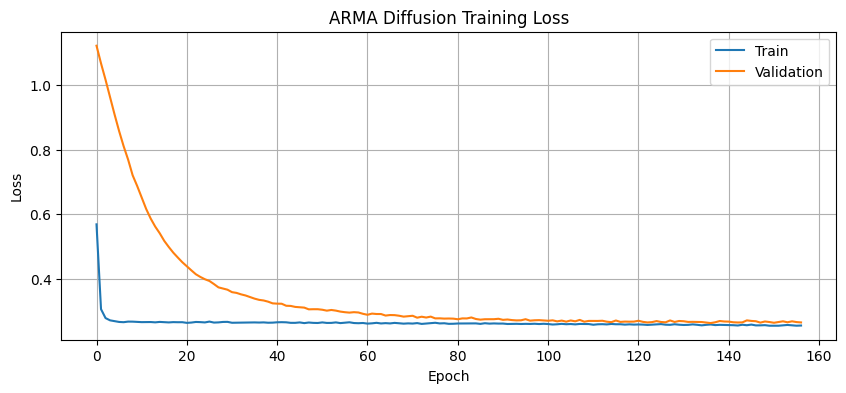

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_df.index, history_df["train_loss"], label="Train")
ax.plot(history_df.index, history_df["val_loss"], label="Validation")
ax.set_title("ARMA Diffusion Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)
plt.show()

## 6. Generate return scenarios

This matches the original diagnostic generation: use the last validation window, generate 100 future steps, and create 2000 paths.

In [13]:
# Sanity check for the original diagnostic generation settings.
ARMA_DIAGNOSTIC_HORIZON = 100
ARMA_DIAGNOSTIC_NUM_SAMPLES = 2000
assert ARMA_DIAGNOSTIC_HORIZON == 100
assert ARMA_DIAGNOSTIC_NUM_SAMPLES == 2000
print("Generation sanity check passed:", ARMA_DIAGNOSTIC_HORIZON, ARMA_DIAGNOSTIC_NUM_SAMPLES)

Generation sanity check passed: 100 2000


In [14]:
history_window = valid_returns[-cfg.context_length:]

scenarios = generate_scenarios(
    model=best_model,
    return_history_window=history_window,
    horizon=ARMA_DIAGNOSTIC_HORIZON,
    num_samples=ARMA_DIAGNOSTIC_NUM_SAMPLES,
    eta=1.0,
    clip_x0=None,
)

generated_returns_standardized = scenarios["returns"].detach().cpu()
generated_rnn_features = scenarios["features"].detach().cpu()

print("Generated standardized returns:")
print(generated_returns_standardized.shape)
print("Generated RNN features:")
print(generated_rnn_features.shape)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


Generated standardized returns:
torch.Size([100, 2000, 5])
Generated RNN features:
torch.Size([100, 2000, 64])


In [15]:
mean_t = torch.as_tensor(mean, dtype=torch.float32).view(1, 1, -1)
std_t = torch.as_tensor(std, dtype=torch.float32).view(1, 1, -1)

generated_returns_raw = generated_returns_standardized * std_t + mean_t

print("Generated raw returns:")
print(generated_returns_raw.shape)

Generated raw returns:
torch.Size([100, 2000, 5])


## 7. Original distribution diagnostics

These are the same diagnostics used in your uploaded ARMA notebook: standardized mean, standardized standard deviation, and centered lag-1 autocorrelation.

In [16]:
real_mean = valid_returns.mean(axis=0)
real_std = valid_returns.std(axis=0)
real_acf1 = acf1_numpy_centered(valid_returns)

gen_flat = generated_returns_standardized.reshape(
    -1,
    generated_returns_standardized.shape[-1],
)

gen_mean = gen_flat.mean(dim=0)
gen_std = gen_flat.std(dim=0)
gen_acf1 = acf1_torch_scenarios_centered(generated_returns_standardized)

print("Real standardized mean:", real_mean)
print("Gen standardized mean: ", gen_mean)

print("Real standardized std:", real_std)
print("Gen standardized std: ", gen_std)

print("Real centered ACF1:", real_acf1)
print("Gen centered ACF1: ", gen_acf1)

Real standardized mean: [ 0.0500707   0.05566951  0.05431141 -0.00476854  0.04675479]
Gen standardized mean:  tensor([ 0.0222,  0.0123, -0.0309, -0.0461, -0.0396])
Real standardized std: [1.0038483  0.9872618  1.0399352  0.95261836 0.9904831 ]
Gen standardized std:  tensor([1.0062, 1.0070, 1.0068, 1.0096, 1.0137])
Real centered ACF1: [0.1537573  0.1570959  0.19062595 0.19466911 0.20281595]
Gen centered ACF1:  tensor([0.1682, 0.1883, 0.1749, 0.1318, 0.1657])


In [17]:
diagnostics_df, diagnostics_summary = arma_distribution_diagnostics(
    real_standardized=valid_returns,
    generated_standardized=generated_returns_standardized,
    asset_names=asset_names,
)

print("Summary metrics:")
for k, v in diagnostics_summary.items():
    print(f"{k}: {v:.6f}")

diagnostics_df.to_csv(OUTPUT_DIR / "arma_distribution_diagnostics.csv", index=False)
pd.Series(diagnostics_summary).to_csv(OUTPUT_DIR / "arma_distribution_diagnostics_summary.csv")
diagnostics_df

Summary metrics:
Mean MAE: 0.056821
Std MAE: 0.027067
ACF1 MAE: 0.032273


,asset,real_mean,gen_mean,abs_mean_error,real_std,gen_std,abs_std_error,real_acf1,gen_acf1,abs_acf1_error
0,Asset_1,0.050071,0.022224,0.027847,1.003848,1.006162,0.002313,0.153757,0.168183,0.014426
1,Asset_2,0.055670,0.012329,0.043340,0.987262,1.006965,0.019703,0.157096,0.188252,0.031156
2,Asset_3,0.054311,-0.030925,0.085236,1.039935,1.006820,0.033115,0.190626,0.174862,0.015764
3,Asset_4,-0.004769,-0.046101,0.041332,0.952618,1.009618,0.057000,0.194669,0.131798,0.062871
4,Asset_5,0.046755,-0.039596,0.086351,0.990483,1.013686,0.023202,0.202816,0.165665,0.037151


## 8. Diagnostic plots

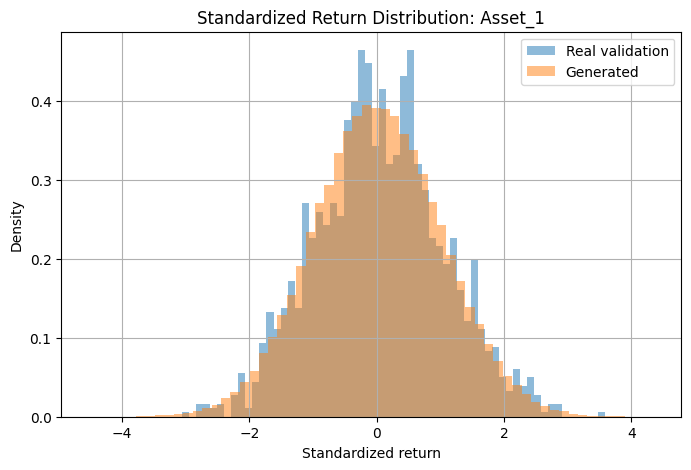

In [18]:
asset_idx = 0
asset_name = asset_names[asset_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(valid_returns[:, asset_idx], bins=60, alpha=0.50, density=True, label="Real validation")
ax.hist(generated_returns_standardized[:, :, asset_idx].reshape(-1).numpy(), bins=60, alpha=0.50, density=True, label="Generated")
ax.set_title(f"Standardized Return Distribution: {asset_name}")
ax.set_xlabel("Standardized return")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True)
plt.show()

In [19]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# ============================================================
# 1. Helper: convert generated tensor to [H, S, D]
# ============================================================

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def ensure_horizon_sample_asset(x, horizon=None):
    """
    Ensures shape is [horizon, num_samples, num_assets].
    Your generated data may be [H, S, D] or [S, H, D].
    """
    x = to_numpy(x)

    if x.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {x.shape}")

    if horizon is None:
        # assume first dim is horizon
        return x

    if x.shape[0] == horizon:
        return x

    if x.shape[1] == horizon:
        return np.transpose(x, (1, 0, 2))

    raise ValueError(
        f"Cannot infer horizon axis. Got shape {x.shape}, horizon={horizon}"
    )


H = ARMA_DIAGNOSTIC_HORIZON
S = ARMA_DIAGNOSTIC_NUM_SAMPLES

generated_std = ensure_horizon_sample_asset(
    generated_returns_standardized,
    horizon=H,
)

H, S, D = generated_std.shape

print("Generated standardized shape [H, S, D]:", generated_std.shape)

Generated standardized shape [H, S, D]: (100, 2000, 5)


In [20]:
# ============================================================
# 2. Conditional ARMA simulation from the same context
# ============================================================



ARMA_AR = (0.10, 0.04, 0.02, 0.01, 0.00)
ARMA_MA = (0.06, 0.03, 0.01, 0.00, 0.00)
ARMA_SIGMA = 0.01
ARMA_CORR = 0.30
ARMA_SEED = 999


def estimate_arma_innovations_from_history(history_raw, ar=(0.35,), ma=(0.25,)):
    """
    Estimate eps_t recursively from observed ARMA history.

    history_raw: [context_length, num_assets]
    """
    history_raw = np.asarray(history_raw, dtype=np.float64)

    L, D = history_raw.shape
    eps_hat = np.zeros_like(history_raw)

    for t in range(L):
        ar_part = np.zeros(D)
        ma_part = np.zeros(D)

        for i, phi in enumerate(ar, start=1):
            if t - i >= 0:
                ar_part += phi * history_raw[t - i]

        for j, theta in enumerate(ma, start=1):
            if t - j >= 0:
                ma_part += theta * eps_hat[t - j]

        eps_hat[t] = history_raw[t] - ar_part - ma_part

    return eps_hat


def simulate_conditional_arma_paths(
    history_raw,
    horizon,
    num_samples,
    ar=(0.35,),
    ma=(0.25,),
    sigma=0.01,
    corr=0.30,
    seed=999,
):
    """
    Simulate conditional ARMA paths from the exact same history window.

    Returns:
        simulated_raw: [horizon, num_samples, num_assets]
    """
    rng = np.random.default_rng(seed)

    history_raw = np.asarray(history_raw, dtype=np.float64)
    L, D = history_raw.shape

    p = len(ar)
    q = len(ma)

    cov = np.full((D, D), corr * sigma**2)
    np.fill_diagonal(cov, sigma**2)

    eps_hist = estimate_arma_innovations_from_history(history_raw, ar=ar, ma=ma)

    simulated = np.zeros((horizon, num_samples, D), dtype=np.float64)

    for s in range(num_samples):
        r_lags = [history_raw[-i].copy() for i in range(1, p + 1)]
        eps_lags = [eps_hist[-j].copy() for j in range(1, q + 1)]

        for h in range(horizon):
            eps_t = rng.multivariate_normal(
                mean=np.zeros(D),
                cov=cov,
            )

            ar_part = np.zeros(D)
            ma_part = np.zeros(D)

            for i, phi in enumerate(ar):
                ar_part += phi * r_lags[i]

            for j, theta in enumerate(ma):
                ma_part += theta * eps_lags[j]

            r_t = ar_part + eps_t + ma_part

            simulated[h, s] = r_t

            if p > 0:
                r_lags = [r_t.copy()] + r_lags[:-1]

            if q > 0:
                eps_lags = [eps_t.copy()] + eps_lags[:-1]

    return simulated


# ------------------------------------------------------------
# Get same context window in raw scale
# ------------------------------------------------------------

mean_vec = np.asarray(mean).reshape(-1)
std_vec = np.asarray(std).reshape(-1)

history_window_std = np.asarray(history_window, dtype=np.float64)

# If you have valid_raw, use it directly.
# Otherwise unstandardize the standardized history window.
try:
    history_window_raw = valid_raw[-cfg.context_length:]
except NameError:
    history_window_raw = history_window_std * std_vec.reshape(1, -1) + mean_vec.reshape(1, -1)

print("History raw shape:", history_window_raw.shape)

# ------------------------------------------------------------
# Simulate true ARMA paths from same history
# ------------------------------------------------------------

simulated_raw = simulate_conditional_arma_paths(
    history_raw=history_window_raw,
    horizon=H,
    num_samples=S,
    ar=ARMA_AR,
    ma=ARMA_MA,
    sigma=ARMA_SIGMA,
    corr=ARMA_CORR,
    seed=ARMA_SEED,
)

simulated_std = (
    simulated_raw - mean_vec.reshape(1, 1, -1)
) / std_vec.reshape(1, 1, -1)

print("Simulated raw shape:", simulated_raw.shape)
print("Simulated standardized shape:", simulated_std.shape)

History raw shape: (36, 5)
Simulated raw shape: (100, 2000, 5)
Simulated standardized shape: (100, 2000, 5)


In [21]:
# ============================================================
# 3. Distribution diagnostics
# ============================================================

def acf1_scenarios_centered(x):
    """
    x: [H, S, D]
    """
    x = np.asarray(x, dtype=np.float64)
    x_centered = x - x.mean(axis=(0, 1), keepdims=True)

    num = (x_centered[:-1] * x_centered[1:]).mean(axis=(0, 1))
    den = (x_centered * x_centered).mean(axis=(0, 1)) + 1e-8

    return num / den


def scenario_stats(x):
    """
    x: [H, S, D]
    """
    x = np.asarray(x, dtype=np.float64)
    flat = x.reshape(-1, x.shape[-1])

    return {
        "mean": flat.mean(axis=0),
        "std": flat.std(axis=0),
        "acf1": acf1_scenarios_centered(x),
        "q025": np.quantile(flat, 0.025, axis=0),
        "q500": np.quantile(flat, 0.500, axis=0),
        "q975": np.quantile(flat, 0.975, axis=0),
    }


gen_stats = scenario_stats(generated_std)
sim_stats = scenario_stats(simulated_std)

asset_names = [f"Asset_{i+1}" for i in range(D)]

diagnostics_df = pd.DataFrame({
    "asset": asset_names,

    "sim_mean": sim_stats["mean"],
    "gen_mean": gen_stats["mean"],
    "abs_mean_error": np.abs(sim_stats["mean"] - gen_stats["mean"]),

    "sim_std": sim_stats["std"],
    "gen_std": gen_stats["std"],
    "abs_std_error": np.abs(sim_stats["std"] - gen_stats["std"]),

    "sim_acf1": sim_stats["acf1"],
    "gen_acf1": gen_stats["acf1"],
    "abs_acf1_error": np.abs(sim_stats["acf1"] - gen_stats["acf1"]),

    "sim_q025": sim_stats["q025"],
    "gen_q025": gen_stats["q025"],
    "abs_q025_error": np.abs(sim_stats["q025"] - gen_stats["q025"]),

    "sim_q975": sim_stats["q975"],
    "gen_q975": gen_stats["q975"],
    "abs_q975_error": np.abs(sim_stats["q975"] - gen_stats["q975"]),
})

summary = {
    "Mean MAE": diagnostics_df["abs_mean_error"].mean(),
    "Std MAE": diagnostics_df["abs_std_error"].mean(),
    "ACF1 MAE": diagnostics_df["abs_acf1_error"].mean(),
    "Q025 MAE": diagnostics_df["abs_q025_error"].mean(),
    "Q975 MAE": diagnostics_df["abs_q975_error"].mean(),
}

print("Generated vs conditional simulated ARMA diagnostics:")
for k, v in summary.items():
    print(f"{k}: {v:.6f}")

diagnostics_df

Generated vs conditional simulated ARMA diagnostics:
Mean MAE: 0.037883
Std MAE: 0.011740
ACF1 MAE: 0.015005
Q025 MAE: 0.062995
Q975 MAE: 0.044018


,asset,sim_mean,gen_mean,abs_mean_error,sim_std,gen_std,abs_std_error,sim_acf1,gen_acf1,abs_acf1_error,sim_q025,gen_q025,abs_q025_error,sim_q975,gen_q975,abs_q975_error
0,Asset_1,0.025912,0.022224,0.003688,0.995287,1.006159,0.010872,0.173472,0.168183,0.005289,-1.931365,-1.939524,0.008159,1.978684,2.002009,0.023326
1,Asset_2,0.020569,0.012329,0.008239,0.987418,1.006962,0.019544,0.172062,0.188252,0.016190,-1.919311,-2.010048,0.090737,1.953748,1.969230,0.015482
2,Asset_3,0.030822,-0.030925,0.061747,1.012336,1.006818,0.005518,0.167122,0.174862,0.007740,-1.953286,-1.994648,0.041362,2.018800,1.925270,0.093530
3,Asset_4,0.007045,-0.046101,0.053146,0.999846,1.009616,0.009770,0.172225,0.131798,0.040427,-1.953322,-2.041737,0.088414,1.963683,1.913349,0.050334
4,Asset_5,0.022997,-0.039596,0.062593,1.000688,1.013683,0.012995,0.171041,0.165665,0.005376,-1.932460,-2.018764,0.086304,1.982413,1.944995,0.037418


In [22]:
# ============================================================
# 4. Cross-sectional correlation matrices
# ============================================================

def cross_section_corr_matrix(x):
    """
    x: [H, S, D]
    Returns correlation matrix across assets: [D, D]
    """
    x = np.asarray(x, dtype=np.float64)
    flat = x.reshape(-1, x.shape[-1])
    return np.corrcoef(flat, rowvar=False)


def offdiag_mae(a, b):
    mask = ~np.eye(a.shape[0], dtype=bool)
    return np.mean(np.abs(a[mask] - b[mask]))


gen_corr = cross_section_corr_matrix(generated_std)
sim_corr = cross_section_corr_matrix(simulated_std)

corr_error = gen_corr - sim_corr
corr_mae = offdiag_mae(gen_corr, sim_corr)

print("Generated cross-sectional correlation:")
print(pd.DataFrame(gen_corr, index=asset_names, columns=asset_names))

print("\nSimulated ARMA cross-sectional correlation:")
print(pd.DataFrame(sim_corr, index=asset_names, columns=asset_names))

print(f"\nOff-diagonal correlation MAE: {corr_mae:.6f}")

Generated cross-sectional correlation:
          Asset_1   Asset_2   Asset_3   Asset_4   Asset_5
Asset_1  1.000000  0.307775  0.323644  0.310980  0.316185
Asset_2  0.307775  1.000000  0.319352  0.308365  0.313909
Asset_3  0.323644  0.319352  1.000000  0.308088  0.314051
Asset_4  0.310980  0.308365  0.308088  1.000000  0.317333
Asset_5  0.316185  0.313909  0.314051  0.317333  1.000000

Simulated ARMA cross-sectional correlation:
          Asset_1   Asset_2   Asset_3   Asset_4   Asset_5
Asset_1  1.000000  0.299967  0.302173  0.300751  0.297864
Asset_2  0.299967  1.000000  0.302853  0.299474  0.297704
Asset_3  0.302173  0.302853  1.000000  0.301562  0.303434
Asset_4  0.300751  0.299474  0.301562  1.000000  0.295171
Asset_5  0.297864  0.297704  0.303434  0.295171  1.000000

Off-diagonal correlation MAE: 0.013873


/tmp/ipykernel_7163/1072776260.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


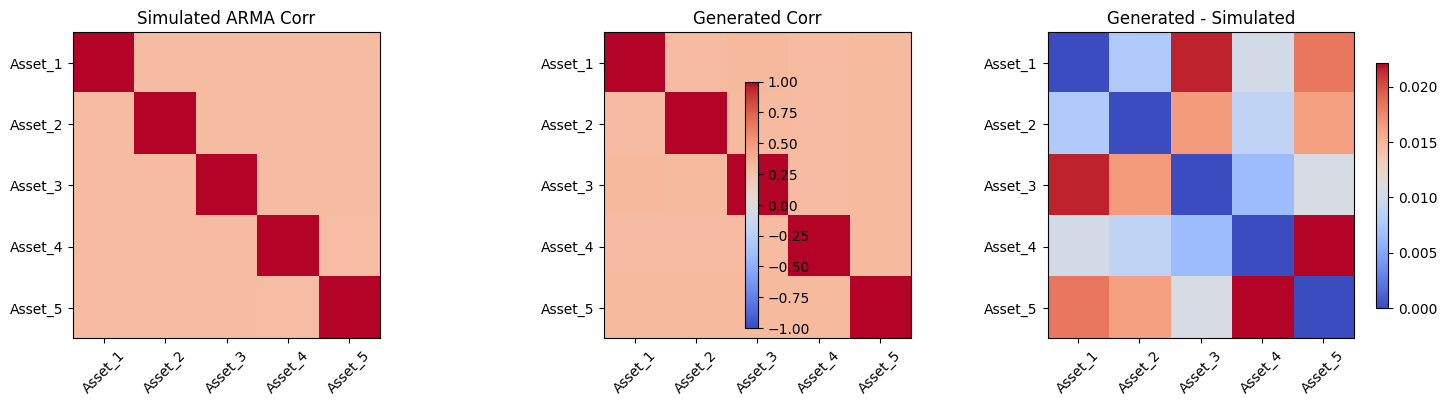

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im0 = axes[0].imshow(sim_corr, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("Simulated ARMA Corr")
axes[0].set_xticks(range(D))
axes[0].set_yticks(range(D))
axes[0].set_xticklabels(asset_names, rotation=45)
axes[0].set_yticklabels(asset_names)

im1 = axes[1].imshow(gen_corr, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Generated Corr")
axes[1].set_xticks(range(D))
axes[1].set_yticks(range(D))
axes[1].set_xticklabels(asset_names, rotation=45)
axes[1].set_yticklabels(asset_names)

im2 = axes[2].imshow(corr_error, cmap="coolwarm")
axes[2].set_title("Generated - Simulated")
axes[2].set_xticks(range(D))
axes[2].set_yticks(range(D))
axes[2].set_xticklabels(asset_names, rotation=45)
axes[2].set_yticklabels(asset_names)

fig.colorbar(im0, ax=axes[:2], shrink=0.8)
fig.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 5. Plot 95% price range for generated and simulated paths
# ============================================================

def returns_to_price_paths(returns, initial_price=100.0):
    """
    Convert return paths to price paths.

    returns: [H, S, D]
        H = horizon
        S = number of scenarios
        D = number of assets

    returns:
        prices: [H + 1, S, D]
        Includes initial price at time 0.
    """
    returns = np.asarray(returns, dtype=np.float64)

    H, S, D = returns.shape

    prices = np.empty((H + 1, S, D), dtype=np.float64)
    prices[0] = initial_price

    prices[1:] = initial_price * np.cumprod(1.0 + returns, axis=0)

    return prices


def plot_95_price_bands(
    generated_returns,
    simulated_returns,
    asset_names=None,
    initial_price=100.0,
    scale_name="raw returns",
):
    """
    Plot 95% price/wealth bands implied by return scenarios.

    generated_returns: [H, S, D]
    simulated_returns: [H, S, D]
    """
    generated_returns = np.asarray(generated_returns, dtype=np.float64)
    simulated_returns = np.asarray(simulated_returns, dtype=np.float64)

    H, S, D = generated_returns.shape

    if asset_names is None:
        asset_names = [f"Asset_{i+1}" for i in range(D)]

    generated_prices = returns_to_price_paths(
        generated_returns,
        initial_price=initial_price,
    )

    simulated_prices = returns_to_price_paths(
        simulated_returns,
        initial_price=initial_price,
    )

    x_axis = np.arange(H + 1)

    gen_mean = generated_prices.mean(axis=1)
    gen_low = np.quantile(generated_prices, 0.025, axis=1)
    gen_high = np.quantile(generated_prices, 0.975, axis=1)

    sim_mean = simulated_prices.mean(axis=1)
    sim_low = np.quantile(simulated_prices, 0.025, axis=1)
    sim_high = np.quantile(simulated_prices, 0.975, axis=1)

    for j in range(D):
        plt.figure(figsize=(11, 5))

        plt.fill_between(
            x_axis,
            sim_low[:, j],
            sim_high[:, j],
            alpha=0.25,
            label="Simulated ARMA 95% price range",
        )

        plt.fill_between(
            x_axis,
            gen_low[:, j],
            gen_high[:, j],
            alpha=0.25,
            label="Generated diffusion 95% price range",
        )

        plt.plot(
            x_axis,
            sim_mean[:, j],
            linewidth=2,
            label="Simulated ARMA mean price",
        )

        plt.plot(
            x_axis,
            gen_mean[:, j],
            linewidth=2,
            linestyle="--",
            label="Generated diffusion mean price",
        )

        plt.axhline(initial_price, linewidth=1)

        plt.title(f"{asset_names[j]}: 95% Price Range from Return Scenarios")
        plt.xlabel("Forecast horizon")
        plt.ylabel(f"Price index, initial={initial_price}")
        plt.legend()
        plt.grid(True)
        plt.show()

    return {
        "generated_prices": generated_prices,
        "simulated_prices": simulated_prices,
        "generated_price_mean": gen_mean,
        "generated_price_low": gen_low,
        "generated_price_high": gen_high,
        "simulated_price_mean": sim_mean,
        "simulated_price_low": sim_low,
        "simulated_price_high": sim_high,
    }

Saved: /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/outputs/arma_original_settings/arma_qq_plots.png
Saved: /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/outputs/arma_original_settings/arma_qq_plots.pdf


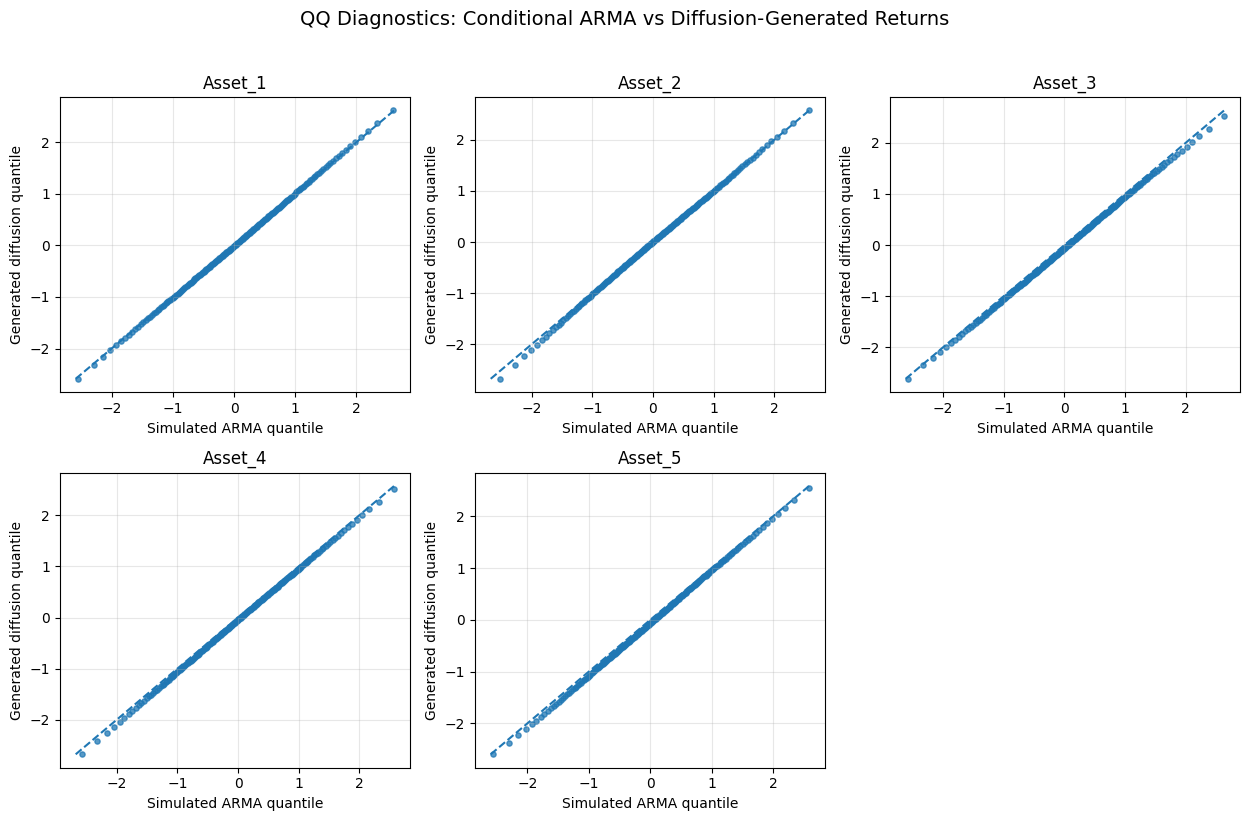

In [25]:
# ============================================================
# Paper-quality ARMA diagnostics:
# QQ plots, box plots, and correlation error heatmap
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Make sure OUTPUT_DIR exists
try:
    OUTPUT_DIR
except NameError:
    OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def flatten_scenarios(x):
    """
    Convert [H, S, D] scenarios into [H*S, D].
    """
    x = np.asarray(x, dtype=np.float64)
    if x.ndim != 3:
        raise ValueError(f"Expected [H, S, D], got {x.shape}")
    return x.reshape(-1, x.shape[-1])


def save_paper_figure(fig, name):
    """
    Save both PNG and PDF versions.
    """
    png_path = OUTPUT_DIR / f"{name}.png"
    pdf_path = OUTPUT_DIR / f"{name}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


# Flatten scenarios
sim_flat = flatten_scenarios(simulated_std)
gen_flat = flatten_scenarios(generated_std)

D = sim_flat.shape[1]

try:
    asset_names
except NameError:
    asset_names = [f"Asset {i+1}" for i in range(D)]


# ============================================================
# 1. QQ plots: simulated ARMA vs generated diffusion
# ============================================================

def plot_arma_qq_grid(
    simulated_flat,
    generated_flat,
    asset_names,
    quantile_grid=None,
    fig_name="arma_qq_plots",
):
    """
    QQ plot for each asset:
    x-axis = true conditional ARMA quantiles
    y-axis = diffusion-generated quantiles
    """
    simulated_flat = np.asarray(simulated_flat)
    generated_flat = np.asarray(generated_flat)

    D = simulated_flat.shape[1]

    if quantile_grid is None:
        # Avoid extreme sample noise at exactly 0 and 1
        quantile_grid = np.linspace(0.005, 0.995, 199)

    ncols = min(3, D)
    nrows = int(np.ceil(D / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 4.0 * nrows),
        squeeze=False,
    )

    for j in range(D):
        ax = axes[j // ncols, j % ncols]

        q_sim = np.quantile(simulated_flat[:, j], quantile_grid)
        q_gen = np.quantile(generated_flat[:, j], quantile_grid)

        ax.scatter(q_sim, q_gen, s=14, alpha=0.75)

        lo = min(q_sim.min(), q_gen.min())
        hi = max(q_sim.max(), q_gen.max())
        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5)

        ax.set_title(asset_names[j])
        ax.set_xlabel("Simulated ARMA quantile")
        ax.set_ylabel("Generated diffusion quantile")
        ax.grid(True, alpha=0.3)

    # Remove unused axes
    for k in range(D, nrows * ncols):
        axes[k // ncols, k % ncols].axis("off")

    fig.suptitle(
        "QQ Diagnostics: Conditional ARMA vs Diffusion-Generated Returns",
        fontsize=14,
        y=1.02,
    )

    fig.tight_layout()
    save_paper_figure(fig, fig_name)
    plt.show()

    return fig


fig_qq = plot_arma_qq_grid(
    simulated_flat=sim_flat,
    generated_flat=gen_flat,
    asset_names=asset_names,
    fig_name="arma_qq_plots",
)

Saved: /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/outputs/arma_original_settings/arma_boxplots.png
Saved: /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/outputs/arma_original_settings/arma_boxplots.pdf


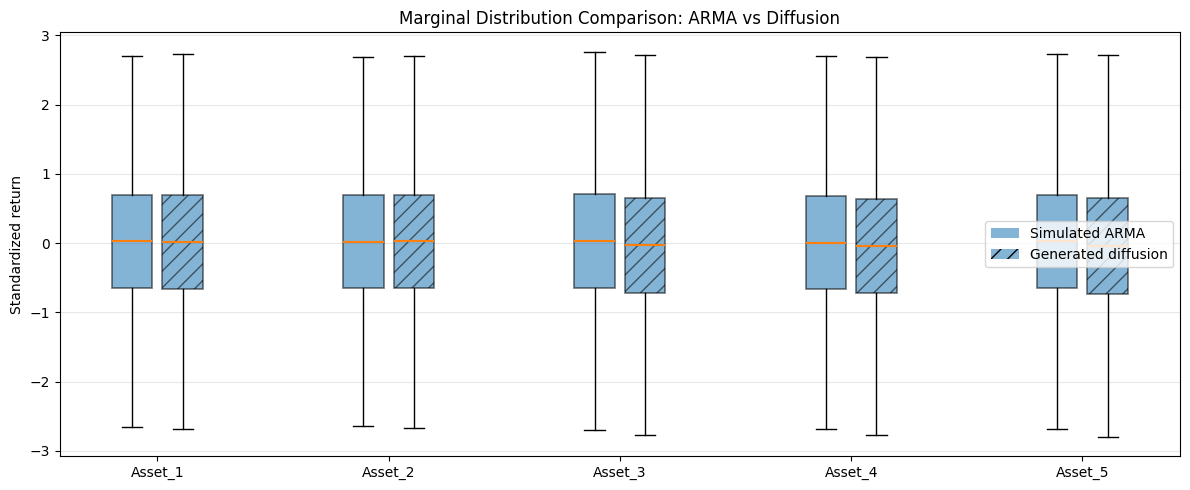

In [26]:
# ============================================================
# 2. Box plots: marginal distribution comparison
# ============================================================

def plot_arma_boxplots(
    simulated_flat,
    generated_flat,
    asset_names,
    fig_name="arma_boxplots",
):
    """
    Side-by-side box plots comparing simulated ARMA and generated diffusion
    standardized returns for each asset.
    """
    simulated_flat = np.asarray(simulated_flat)
    generated_flat = np.asarray(generated_flat)

    D = simulated_flat.shape[1]

    data = []
    positions = []
    tick_positions = []

    base_gap = 1.6
    within_gap = 0.35

    for j in range(D):
        center = j * base_gap + 1.0

        data.append(simulated_flat[:, j])
        positions.append(center - within_gap / 2)

        data.append(generated_flat[:, j])
        positions.append(center + within_gap / 2)

        tick_positions.append(center)

    fig, ax = plt.subplots(figsize=(1.8 * D + 3, 5))

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.28,
        showfliers=False,
        patch_artist=True,
        medianprops={"linewidth": 1.5},
        boxprops={"linewidth": 1.2},
        whiskerprops={"linewidth": 1.0},
        capprops={"linewidth": 1.0},
    )

    # Use hatch patterns rather than relying only on color
    for i, box in enumerate(bp["boxes"]):
        if i % 2 == 0:
            box.set_hatch("")
            box.set_alpha(0.55)
        else:
            box.set_hatch("//")
            box.set_alpha(0.55)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(asset_names)
    ax.set_ylabel("Standardized return")
    ax.set_title("Marginal Distribution Comparison: ARMA vs Diffusion")
    ax.grid(True, axis="y", alpha=0.3)

    # Dummy handles for legend
    sim_handle = plt.Rectangle((0, 0), 1, 1, alpha=0.55, label="Simulated ARMA")
    gen_handle = plt.Rectangle((0, 0), 1, 1, alpha=0.55, hatch="//", label="Generated diffusion")
    ax.legend(handles=[sim_handle, gen_handle], loc="best")

    fig.tight_layout()
    save_paper_figure(fig, fig_name)
    plt.show()

    return fig


fig_box = plot_arma_boxplots(
    simulated_flat=sim_flat,
    generated_flat=gen_flat,
    asset_names=asset_names,
    fig_name="arma_boxplots",
)

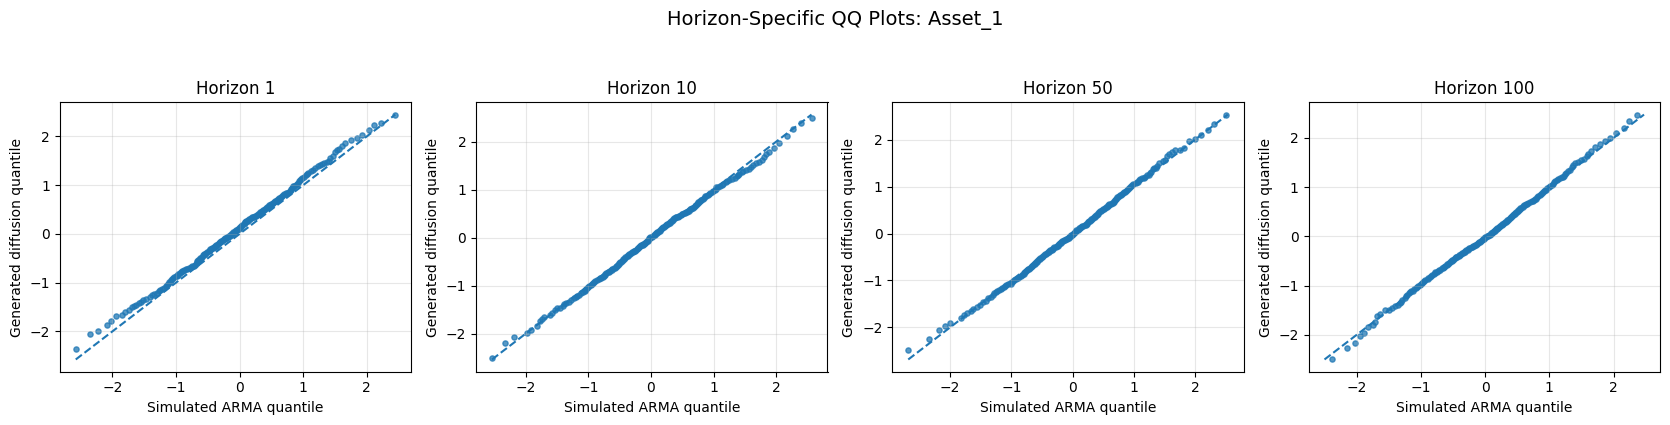

In [27]:
# ============================================================
# Horizon-specific QQ plots
# Compare simulated vs generated at selected forecast horizons
# ============================================================

def plot_qq_by_horizon(
    simulated_std,
    generated_std,
    asset_names,
    horizons=(1, 10, 50, 100),
    asset_idx=0,
    fig_name="arma_qq_by_horizon_asset1",
):
    """
    QQ plots at selected forecast horizons for one asset.

    simulated_std: [H, S, D]
    generated_std: [H, S, D]
    horizons: 1-based horizons to plot
    asset_idx: which asset to plot
    """

    simulated_std = np.asarray(simulated_std)
    generated_std = np.asarray(generated_std)

    H, S, D = simulated_std.shape

    quantile_grid = np.linspace(0.005, 0.995, 199)

    ncols = len(horizons)
    fig, axes = plt.subplots(1, ncols, figsize=(4.2 * ncols, 4), squeeze=False)

    for k, h in enumerate(horizons):
        h_idx = h - 1

        if h_idx < 0 or h_idx >= H:
            raise ValueError(f"Horizon {h} is outside available range 1 to {H}")

        sim_vals = simulated_std[h_idx, :, asset_idx]
        gen_vals = generated_std[h_idx, :, asset_idx]

        q_sim = np.quantile(sim_vals, quantile_grid)
        q_gen = np.quantile(gen_vals, quantile_grid)

        ax = axes[0, k]

        ax.scatter(q_sim, q_gen, s=14, alpha=0.75)

        lo = min(q_sim.min(), q_gen.min())
        hi = max(q_sim.max(), q_gen.max())
        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5)

        ax.set_title(f"Horizon {h}")
        ax.set_xlabel("Simulated ARMA quantile")
        ax.set_ylabel("Generated diffusion quantile")
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f"Horizon-Specific QQ Plots: {asset_names[asset_idx]}",
        fontsize=14,
        y=1.05,
    )

    fig.tight_layout()

    if "OUTPUT_DIR" in globals():
        fig.savefig(OUTPUT_DIR / f"{fig_name}.png", dpi=300, bbox_inches="tight")
        fig.savefig(OUTPUT_DIR / f"{fig_name}.pdf", bbox_inches="tight")

    plt.show()

    return fig


fig_qq_horizon = plot_qq_by_horizon(
    simulated_std=simulated_std,
    generated_std=generated_std,
    asset_names=asset_names,
    horizons=(1, 10, 50, 100),
    asset_idx=0,
    fig_name="arma_qq_by_horizon_asset1",
)

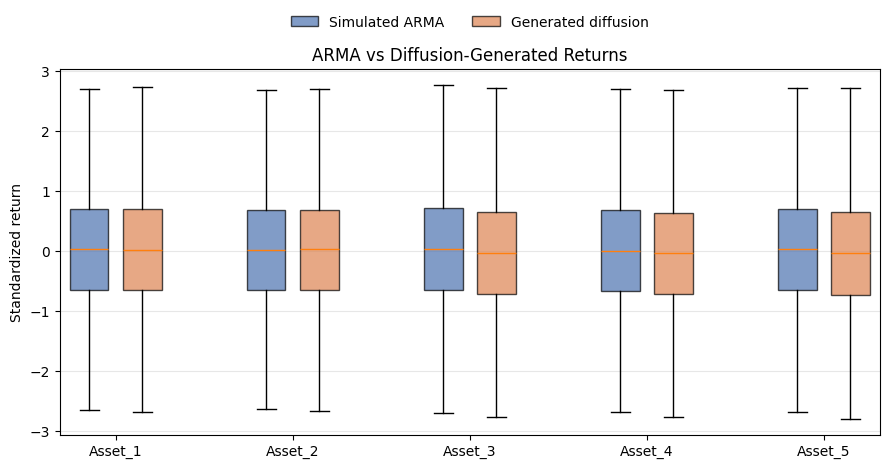

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def flatten_scenarios(x):
    x = np.asarray(x, dtype=np.float64)
    return x.reshape(-1, x.shape[-1])

sim_flat = flatten_scenarios(simulated_std)
gen_flat = flatten_scenarios(generated_std)

D = sim_flat.shape[1]
positions_sim = np.arange(D) * 3.0
positions_gen = positions_sim + 0.9

fig, ax = plt.subplots(figsize=(9, 4.8))

bp1 = ax.boxplot(
    [sim_flat[:, j] for j in range(D)],
    positions=positions_sim,
    widths=0.65,
    patch_artist=True,
    showfliers=False,
)

bp2 = ax.boxplot(
    [gen_flat[:, j] for j in range(D)],
    positions=positions_gen,
    widths=0.65,
    patch_artist=True,
    showfliers=False,
)

for patch in bp1["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.70)

for patch in bp2["boxes"]:
    patch.set_facecolor("#DD8452")
    patch.set_alpha(0.70)

ax.set_xticks(positions_sim + 0.45)
ax.set_xticklabels(asset_names)
ax.set_ylabel("Standardized return")
ax.set_title("ARMA vs Diffusion-Generated Returns")
ax.grid(True, axis="y", alpha=0.3)

ax.legend(
    [bp1["boxes"][0], bp2["boxes"][0]],
    ["Simulated ARMA", "Generated diffusion"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=2,
    frameon=False,
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "arma_boxplots_clean.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "arma_boxplots_clean.pdf", bbox_inches="tight")
plt.show()